In [9]:
import sys
sys.path.append("../")

import torch
import matplotlib.pyplot as plt
import imodal
device = 'cpu'
imodal.Utilities.set_compute_backend('torch')
dtype = torch.float32

In [10]:
col_source = 'dodgerblue'
col_target = 'limegreen'
col_grid = 'black'
alpha_grid = 0.2

(-2.2593750834465025,
 2.530208337306976,
 -1.4078946471214295,
 2.9342105746269227)

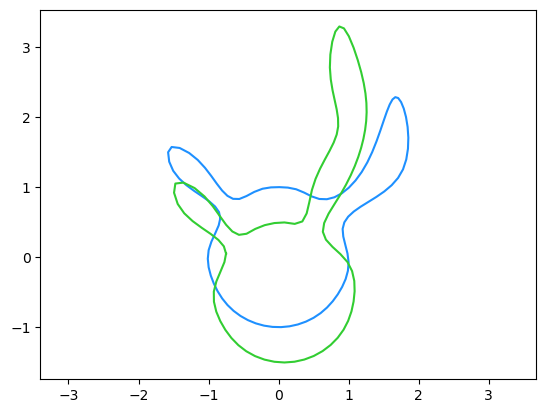

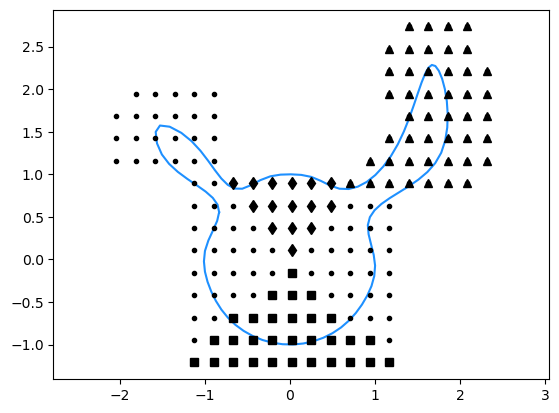

In [11]:
# load data
path_data = '../data/'
source = torch.load(path_data + 'rabbit_source.pt')
target = torch.load(path_data + 'rabbit_target.pt')

# load control points and segmentation
pts_imp = torch.load(path_data + 'rabbit_CP.pt')
index_ear_right = torch.load(path_data + 'rabbit_index_ear_right.pt')
indi_top = torch.load(path_data + 'rabbit_index_top.pt')
indi_bottom = torch.load(path_data + 'rabbit_index_bottom.pt')

plt.figure()
plt.plot(source[:,0], source[:,1], color=col_source)
plt.plot(target[:,0], target[:,1], color=col_target)
plt.axis('equal')
plt.figure()
plt.plot(source[:,0], source[:,1], color=col_source)
plt.plot(pts_imp[:,0], pts_imp[:,1], '.', color=col_grid)
plt.plot(pts_imp[index_ear_right, 0], pts_imp[index_ear_right, 1], '^', color=col_grid)
plt.plot(pts_imp[indi_top, 0], pts_imp[indi_top, 1], 'd', color=col_grid)
plt.plot(pts_imp[indi_bottom, 0], pts_imp[indi_bottom, 1], 's', color=col_grid)
plt.axis('equal')


In [13]:
# defining  implicit module M^1 (generating elongation of right ear)

## Initial orthonormal frames will be built at each iteration of the optimisation via a callback function 'precompute'
## They are all = Id but these of the right ear where they are rotation matrix defined
## by an angle equal to a weighted mean

def distsigmoid(x, lam, alpha):
    return 1./( 1. + torch.exp(-lam * (x - alpha)) )

def compute_basis(angles, gd, alpha):
    """
    angles: list of 2 angles
    gd: gd of implicit deformation module M^1
    alpha: center point for sigmoid distance

    returns : R tensor N x 2 x 2 orthonormal frames

    """
    points, _ = gd
    Nright = len(index_ear_right)
    N = points.shape[0]
    no = torch.norm(points[:Nright], dim=1)
    Z_earright = distsigmoid(no, 5., alpha)
    angles_right = angles[1] * Z_earright + angles[0] * (1-Z_earright)
    angles_tot = torch.cat([angles_right, torch.zeros(N - Nright)])
    X = torch.cos(angles_tot)
    Y = torch.sin(angles_tot)
    e_1 = torch.stack([X, Y], dim=-1).reshape(-1, 2, 1)
    e_2 = torch.stack([-Y, X], dim=-1).reshape(-1, 2, 1)
    R= torch.cat([e_1, e_2], dim=2)
    return R


def precompute(init_manifold, modules, parameters, _):
    init_manifold[2].gd = (init_manifold[2].gd[0], compute_basis(parameters['growth']['params'][0], init_manifold[2].gd, parameters['growth']['params'][1]))



## growth model operator : null everywhere but in the right ear
## where it is an elongation in the direction of the second eigen vector of the orthonormal frame
N = pts_imp.shape[0]
C1 = torch.zeros(N, 2, 1)
Nright = len(index_ear_right)
C1[:Nright, 1, 0] = 1

## Initialisation of parameters for M^1
angles = torch.zeros(2)
alpha = torch.tensor([2.], requires_grad=True)
#angles[1] = -math.pi / 4
angles.requires_grad = True
R1 = compute_basis(angles, [pts_imp, _], alpha)


nu = 1e-6* N
coeff_growth = 0.01
scale_growth1 = 1.

growth1 = imodal.DeformationModules.ImplicitModule1(2, N,
                                                   scale_growth1, C1,
                                                   coeff=coeff_growth,
                                                   nu=nu,
                                                   gd=(pts_imp, R1)
                                                  )


(-1.7488934218883514,
 2.0248699605464937,
 -1.1634739637374878,
 2.4491714239120483)

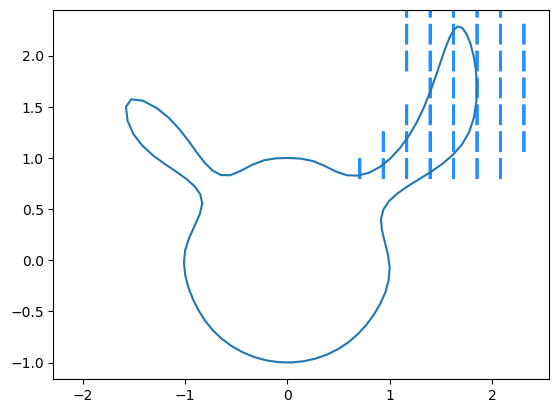

In [50]:
# Plotting initial growth factor for M^1
ax = plt.subplot()
plt.plot(source[:,0], source[:,1], '-')
imodal.Utilities.plot_C_ellipses(ax, pts_imp, C1,
                                    R=R1, color=col_source, scale=0.2,
                                    zorder=1, alpha=1, lw=2)
plt.axis('equal')

In [45]:
# defining  implicit module M^2 (modification of the gap between the ears)

## Orthonormal frames are initialized tangentially
transformation_mat = torch.stack([torch.eye(2), imodal.Utilities.rot2d(0.5 * torch.pi)], dim=0)
R2 = torch.einsum('ijk,lk -> lji', transformation_mat, pts_imp)
# normalizing
no = torch.norm(pts_imp, dim=1)
index_positive_norm = torch.where(no>1e-4)[0]
normalization = 1 / no[index_positive_norm]
R2[index_positive_norm] = R2[index_positive_norm] * normalization.view(-1, 1, 1)

## growth model operator : null everywhere but in 'top' and 'bottom' regions
## of the head where a tangential growth is allowed
C2 = torch.zeros(N, 2, 2)
C2[indi_top, 1, 0] = 1. # first component of the control: tangential growth/shrinking on the top points
C2[indi_bottom, 1, 1] = 1. # second component of the control: tangential growth/shrinking on the bottom points

scale_growth2 = 0.5
growth2 = imodal.DeformationModules.ImplicitModule1(2, N,
                                                   scale_growth2, C2,
                                                   coeff=coeff_growth,
                                                   nu=nu,
                                                   gd=(pts_imp, R2)
                                                  )

(-1.7488934218883514,
 2.0248699605464937,
 -1.1634739637374878,
 2.4491714239120483)

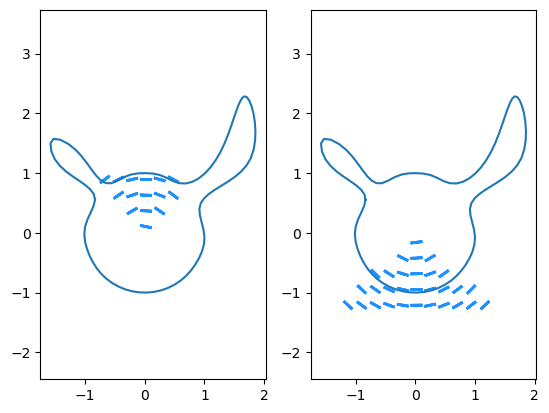

In [53]:
# Plotting first component of growth model operator for M^2
ax = plt.subplot(1, 2, 1)
plt.plot(source[:,0], source[:,1], '-')
imodal.Utilities.plot_C_ellipses(ax, pts_imp, C2,
                                    R=R2, color=col_source, scale=0.2,
                                    zorder=1, alpha=1, lw=2)
plt.axis('equal')

# Plotting second component of growth model operator for M^2
ax = plt.subplot(1, 2, 2)
plt.plot(source[:,0], source[:,1], '-')
imodal.Utilities.plot_C_ellipses(ax, pts_imp, C2[:,:,1].unsqueeze(2),
                                    R=R2, color=col_source, scale=0.2,
                                    zorder=1, alpha=1, lw=2)
plt.axis('equal')

In [15]:
# addition of global rotation and translation
rotation = imodal.DeformationModules.LocalRotation(2, 8.)
point_rotation = torch.tensor([[0., 0.]])
rotation.manifold.fill_gd(point_rotation)

global_translation = imodal.DeformationModules.GlobalTranslation(2, coeff=2.)


In [16]:
deformable_shape_source = imodal.Models.DeformablePoints(source)
deformable_shape_target = imodal.Models.DeformablePoints(target)

In [54]:
model = imodal.Models.RegistrationModel([deformable_shape_source],
                [global_translation, growth1, rotation, growth2],
                [imodal.Attachment.VarifoldAttachment(2, [3., 0.5], backend='torch')],
                lam=500., fit_gd=None,
                precompute_callback=precompute, other_parameters={'growth': {'params': [angles, alpha]}})


In [55]:
shoot_solver = 'rk4'
shoot_it = 5
costs = {}
fitter = imodal.Models.Fitter(model, optimizer='torch_lbfgs')
fitter.fit([deformable_shape_target], 100, costs=costs, options={'shoot_solver': shoot_solver, 'shoot_it': shoot_it, 'line_search_fn': 'strong_wolfe', 'max_iter':1,  'max_eval':1})

Starting optimization with method torch LBFGS, using solver rk4 with 5 iterations.
Initial cost={'deformation': 0.0, 'attach': 11147.8076171875}
1e-10
Evaluated model with costs=11147.8076171875
Evaluated model with costs=9661.326940953732
Time: 27.27058289300021
Iteration: 0
Costs
deformation=0.5984253287315369
attach=9660.728515625
Total cost=9661.326940953732
1e-10
Evaluated model with costs=9661.326940953732
Evaluated model with costs=9623.692659437656
Time: 40.92466074099957
Iteration: 1
Costs
deformation=0.5188313126564026
attach=9623.173828125
Total cost=9623.692659437656
1e-10
Evaluated model with costs=9623.692659437656
Evaluated model with costs=9585.394914269447
Time: 54.03217993199996
Iteration: 2
Costs
deformation=0.49061739444732666
attach=9584.904296875
Total cost=9585.394914269447
1e-10
Evaluated model with costs=9585.394914269447
Evaluated model with costs=9499.968927443027
Time: 66.80311607600015
Iteration: 3
Costs
deformation=0.47283369302749634
attach=9499.49609375


{'c1': [], 'c2': [], 'c3': []}

In [57]:
# Computing estimated deformation
intermediates = {}
with torch.autograd.no_grad():
    deformed = model.compute_deformed(shoot_solver, shoot_it, intermediates=intermediates)


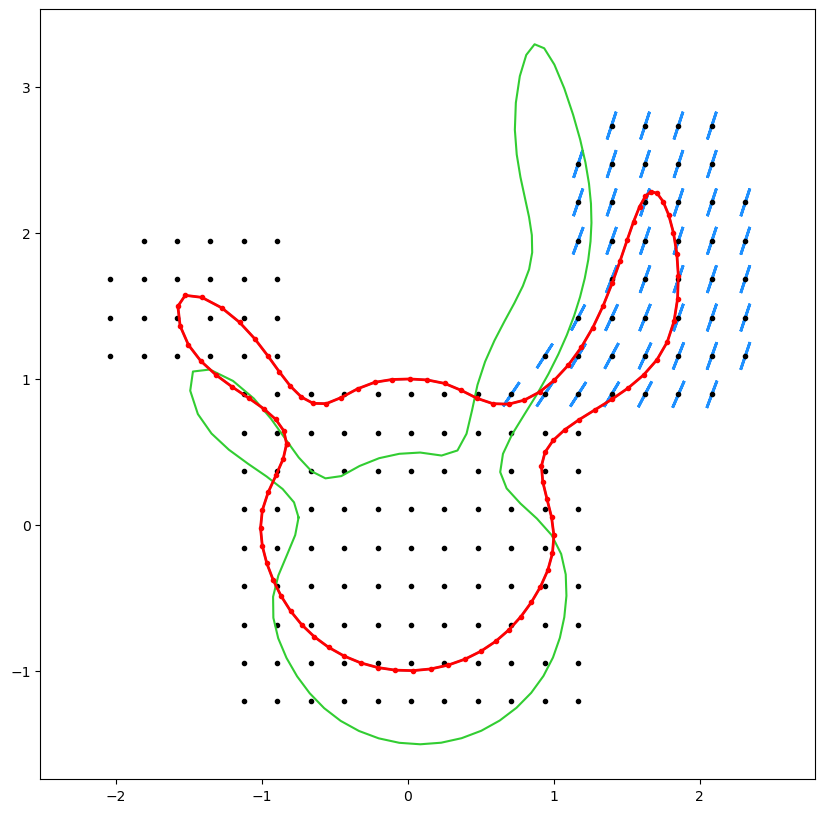

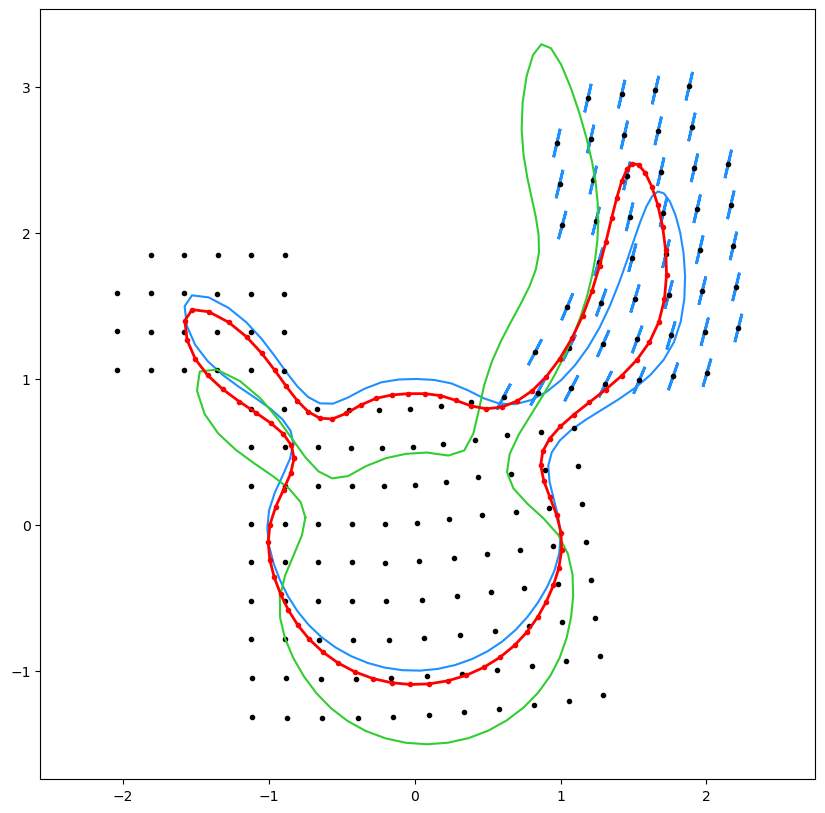

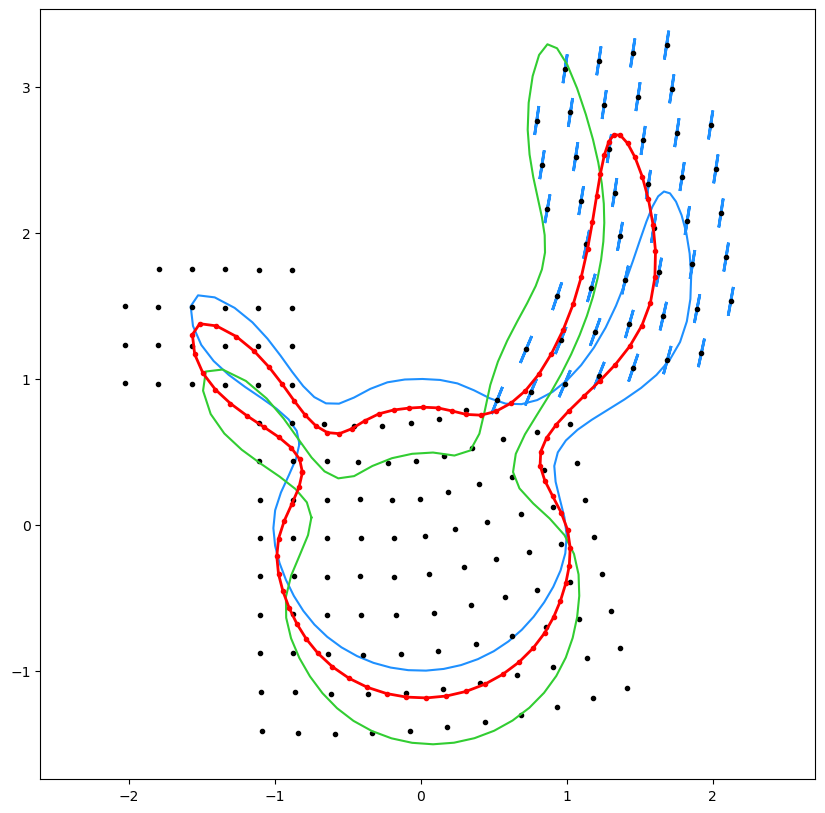

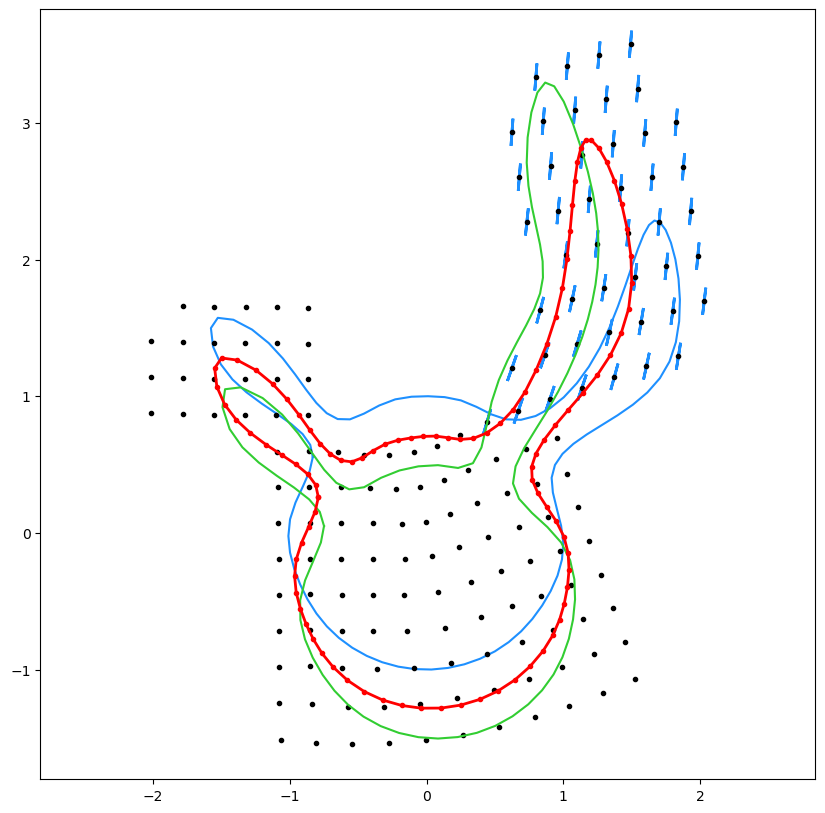

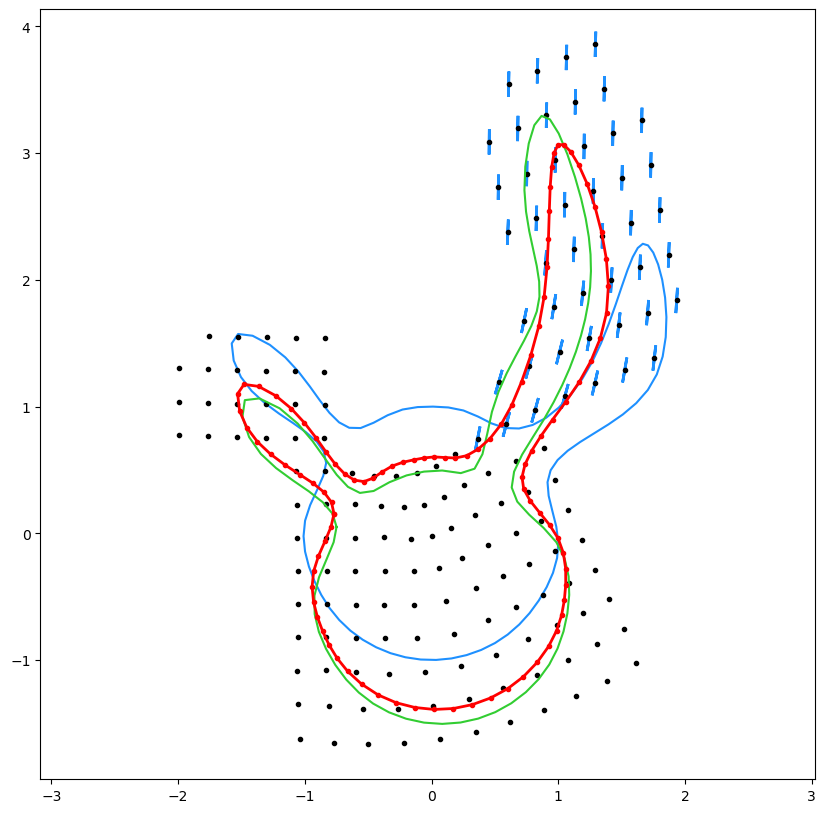

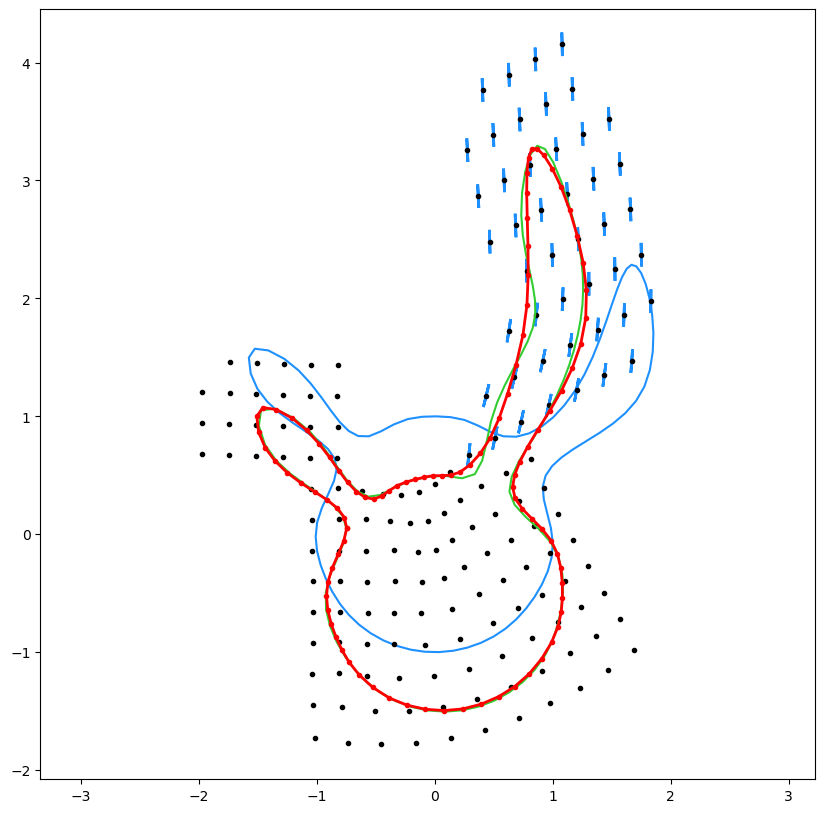

In [58]:
# Plotting estimated deformation with growth factor of M^1

tar = deformable_shape_target.geometry[0]
for i in range(shoot_it + 1):
    plt.figure(figsize=(10,10))
    ax = plt.subplot()
    state = intermediates['states'][i]

    plt.plot(source[:, 0].numpy(), source[:, 1].numpy(), color=col_source)
    plt.plot(state[2].gd[0][:, 0].numpy(), state[2].gd[0][:, 1].numpy(), '.', color=col_grid, lw=1)
    plt.plot(tar[:, 0].numpy(), tar[:, 1].numpy(), color=col_target)
    plt.plot(state[0].gd[:, 0].numpy(), state[0].gd[:, 1].numpy(),'.-', color='red', lw=2)

    pts_imp_t = state.gd[2][0]
    R1_t = state.gd[2][1]

    imodal.Utilities.plot_C_ellipses(ax, pts_imp_t, C1,
                                        R=R1_t, color=col_source, scale=0.2,
                                        zorder=1, alpha=1, lw=2)

    plt.axis('equal')

